In [53]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

from collections import Counter

from datasets import load_dataset



In [54]:
# Load SMS Spam dataset
print('Loading SMS Spam dataset...')
sms_data = load_dataset('ucirvine/sms_spam', split='train')
dataset_split = sms_data.train_test_split(
    test_size=0.2, seed=42, stratify_by_column='label'
)
train_data = dataset_split['train']
test_data = dataset_split['test']
print(f'Training examples: {len(train_data)}')
print(f'Test examples: {len(test_data)}')


Loading SMS Spam dataset...
Training examples: 4459
Test examples: 1115


In [55]:
print(train_data)
print(train_data[0])


Dataset({
    features: ['sms', 'label'],
    num_rows: 4459
})
{'sms': 'Dont you have message offer\n', 'label': 0}


In [56]:
train_sentences = [example['sms'].split() for example in train_data]
train_labels = train_data['label']
test_sentences = [example['sms'].split() for example in test_data]
test_labels = test_data['label']
print(f'First training sentence: {train_sentences[0]}')

vocab = {
    '<PAD>': 0,
    '<UNK>': 1
}

word_counts = Counter()

for sentence in train_sentences:
    word_counts.update(sentence)

for word, count in word_counts.items():
    if count >= 2:
        vocab[word] = len(vocab)

print(f'Vocabulary size: {len(vocab)}')
print(f'Sample vocab: {list(vocab.items())[:10]}')



First training sentence: ['Dont', 'you', 'have', 'message', 'offer']
Vocabulary size: 5353
Sample vocab: [('<PAD>', 0), ('<UNK>', 1), ('Dont', 2), ('you', 3), ('have', 4), ('message', 5), ('offer', 6), ('Ü', 7), ('all', 8), ('write', 9)]


In [57]:
import os
import gdown

file_id = "1WTbdKo7sNTfvRim2Sxm_aSNn2sCibe1q"
url = f"https://drive.google.com/uc?id={file_id}"
output = "glove_vectors.txt"

if not os.path.exists(output):
    print("Downloading GloVe vectors...")
    gdown.download(url, output, quiet=False)
else:
    print("GloVe vectors already downloaded. Skipping download.")

GloVe vectors already downloaded. Skipping download.


In [58]:
EMBEDDING_DIM = 100

glove_vectors = {}

with open("glove_vectors.txt", "r", encoding="utf-8") as f:
    for line in f:
        values = line.rstrip().split(" ")
        word = values[0]
        vector = np.array(values[1:], dtype="float32")

        if len(vector) == EMBEDDING_DIM:
            glove_vectors[word] = vector

print(f"Loaded {len(glove_vectors):,} GloVe vectors")

Loaded 1,291,147 GloVe vectors


In [59]:
embedding_matrix = np.random.randn(
    len(vocab),
    EMBEDDING_DIM
).astype("float32") * 0.01

for word, idx in vocab.items():

    if word == "<PAD>":
        embedding_matrix[idx] = np.zeros(
            EMBEDDING_DIM,
            dtype="float32"
        )

    elif word in glove_vectors:
        embedding_matrix[idx] = glove_vectors[word]
        
        
print(f"Embedding matrix shape: {embedding_matrix.shape}")



Embedding matrix shape: (5353, 100)


In [60]:

class SMSDataset(Dataset):
    def __init__(self,messages, labels, vocab):
        self.messages = messages
        self.labels = labels
        self.vocab = vocab

    def __len__(self):
        return len(self.messages)

    def __getitem__(self, idx):
        message = self.messages[idx]
        label = self.labels[idx]

        # Convert message to indices
        message_indices = [
            self.vocab.get(word, self.vocab["<UNK>"]) for word in message
        ]
        if not message_indices:
            message_indices = [self.vocab['<UNK>']]

        return torch.tensor(message_indices, dtype=torch.long), torch.tensor(label, dtype=torch.long)

    

In [61]:
# Take several SMS messages of different lengths and pad them to the same length
def collate_fn(batch):
    
    messages, labels = zip(*batch)

    lengths = torch.tensor([len(message) for message in messages])

    padded_messages = pad_sequence(
        messages,
        batch_first=True,
        padding_value=vocab['<PAD>']
    )

    labels = torch.stack(labels)

    return padded_messages, labels, lengths

In [62]:
BATCH_SIZE = 32

train_dataset = SMSDataset(train_sentences, train_labels, vocab)
test_dataset = SMSDataset(test_sentences, test_labels, vocab)

train_dataloader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn
)
test_dataloader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn
)


In [63]:
class VanillaRNN(nn.Module):
    def __init__(self,embedding_dim, hidden_dim, output_dim, embedding_matrix):
        super(VanillaRNN, self).__init__()

        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix),
            freeze=False
        )

        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
     embedded = self.embedding(x)
     output, hidden = self.rnn(embedded)
     last_hidden = hidden[-1]
     logits = self.fc(last_hidden)
     return logits 

In [64]:
RNN_HIDDEN_DIM = 128
OUTPUT_DIM = 2

RNN_Model = VanillaRNN(embedding_dim=EMBEDDING_DIM, hidden_dim=RNN_HIDDEN_DIM, output_dim=OUTPUT_DIM, embedding_matrix=embedding_matrix)



Epoch 10/100 - loss: 0.3762
Epoch 20/100 - loss: 0.3896
Epoch 30/100 - loss: 0.2682
Epoch 40/100 - loss: 0.1715
Epoch 50/100 - loss: 0.1972
Epoch 60/100 - loss: 0.1873
Epoch 70/100 - loss: 0.2293
Epoch 80/100 - loss: 0.3747
Epoch 90/100 - loss: 0.2728
Epoch 100/100 - loss: 0.2604
Test accuracy: 87.53%
Test F1 score: 0.1258
Confusion matrix:
[[966   0]
 [139  10]]


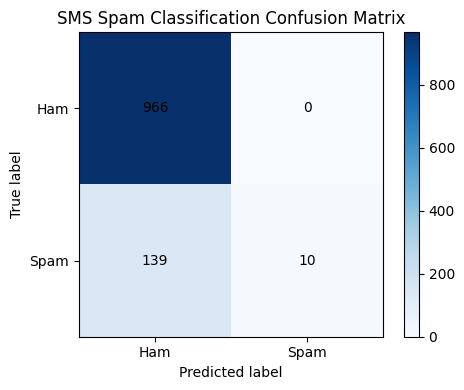

              precision    recall  f1-score   support

           0     0.8742    1.0000    0.9329       966
           1     1.0000    0.0671    0.1258       149

    accuracy                         0.8753      1115
   macro avg     0.9371    0.5336    0.5293      1115
weighted avg     0.8910    0.8753    0.8250      1115



In [67]:
from sklearn.metrics import f1_score

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

NUM_EPOCHS = 100
LEARNING_RATE = 1e-3

RNN_Model = RNN_Model.to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    RNN_Model.parameters(),
    lr=LEARNING_RATE
)

for epoch in range(NUM_EPOCHS):

    RNN_Model.train()
    running_loss = 0.0

    for messages, labels, lengths in train_dataloader:

        messages = messages.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        logits = RNN_Model(messages)

        loss = criterion(logits, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * labels.size(0)

    epoch_loss = running_loss / len(train_dataset)

    if (epoch + 1) % 10 == 0:
        print(
            f'Epoch {epoch + 1}/{NUM_EPOCHS} - '
            f'loss: {epoch_loss:.4f}'
        )


RNN_Model.eval()

test_predictions = []
test_targets = []

with torch.no_grad():

    for messages, labels, lengths in test_dataloader:

        messages = messages.to(DEVICE)

        logits = RNN_Model(messages)

        predictions = logits.argmax(dim=1)

        test_predictions.extend(
            predictions.cpu().tolist()
        )

        test_targets.extend(
            labels.tolist()
        )


test_accuracy = accuracy_score(
    test_targets,
    test_predictions
)

print(f'Test accuracy: {test_accuracy:.2%}')

test_f1 = f1_score(test_targets, test_predictions, zero_division=0)
print(f'Test F1 score: {test_f1:.4f}')

confusion = confusion_matrix(test_targets, test_predictions)
print('Confusion matrix:')
print(confusion)

plt.figure(figsize=(5, 4))
plt.imshow(confusion, cmap='Blues')
plt.title('SMS Spam Classification Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.xticks([0, 1], ['Ham', 'Spam'])
plt.yticks([0, 1], ['Ham', 'Spam'])

for row, values in enumerate(confusion):
    for column, value in enumerate(values):
        plt.text(column, row, value, ha='center', va='center')

plt.colorbar()
plt.tight_layout()
plt.show()

print(
    classification_report(
        test_targets,
        test_predictions,
        digits=4
    )
)